In [1]:
# Install Libraries
!pip install matplotlib numpy

In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import json

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [3]:
# Create Warehouse Grid
grid = np.zeros((20,20),dtype=int)

print(grid)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [4]:
# Add Warehouse Shelves (Obstacles)
obstacles = [

    (4,5),(5,5),(6,5),(7,5),

    (10,9),(11,9),(12,9),(13,9),

    (5,14),(6,14),(7,14),(8,14),

    (15,4),(15,5),(15,6),(15,7)

]

for obs in obstacles:

    grid[obs]=1

In [5]:
# Place Three Robots
robots = {

    "A":(1,1),

    "B":(1,18),

    "C":(18,1)

}

for pos in robots.values():

    grid[pos]=2

In [6]:
# Add Packages
packages=[

    (4,10),

    (12,4),

    (17,17)

]

for p in packages:

    grid[p]=3

In [7]:
# Delivery Locations
targets=[

    (2,17),

    (18,10),

    (5,2)

]

for t in targets:

    grid[t]=4

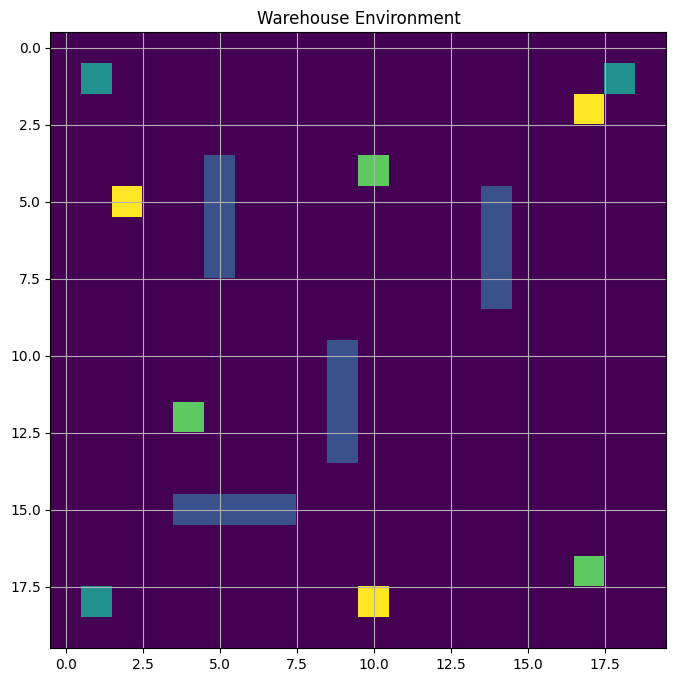

In [8]:
# Display Warehouse
plt.figure(figsize=(8,8))

plt.imshow(grid,cmap="viridis")

plt.title("Warehouse Environment")

plt.grid(True)

plt.show()

In [9]:
# Assign Tasks
tasks={

    "Robot A":{

        "Package":packages[0],

        "Target":targets[0]

    },

    "Robot B":{

        "Package":packages[1],

        "Target":targets[1]

    },

    "Robot C":{

        "Package":packages[2],

        "Target":targets[2]

    }

}

print("TASK ASSIGNMENTS")
print("="*40)

for robot,task in tasks.items():

    print(robot)

    print(" Package :",task["Package"])

    print(" Deliver :",task["Target"])

    print()

TASK ASSIGNMENTS
Robot A
 Package : (4, 10)
 Deliver : (2, 17)

Robot B
 Package : (12, 4)
 Deliver : (18, 10)

Robot C
 Package : (17, 17)
 Deliver : (5, 2)



In [10]:
# Define Simple Paths
path_A = [
(1,1),(2,2),(3,4),(4,6),(4,8),(4,10),
(3,12),(2,15),(2,17)
]

path_B = [
(1,18),(3,17),(5,15),(7,13),(9,11),
(12,4),(14,6),(16,8),(18,10)
]

path_C = [
(18,1),(18,4),(18,8),(18,12),(17,17),
(14,14),(11,10),(8,6),(5,2)
]

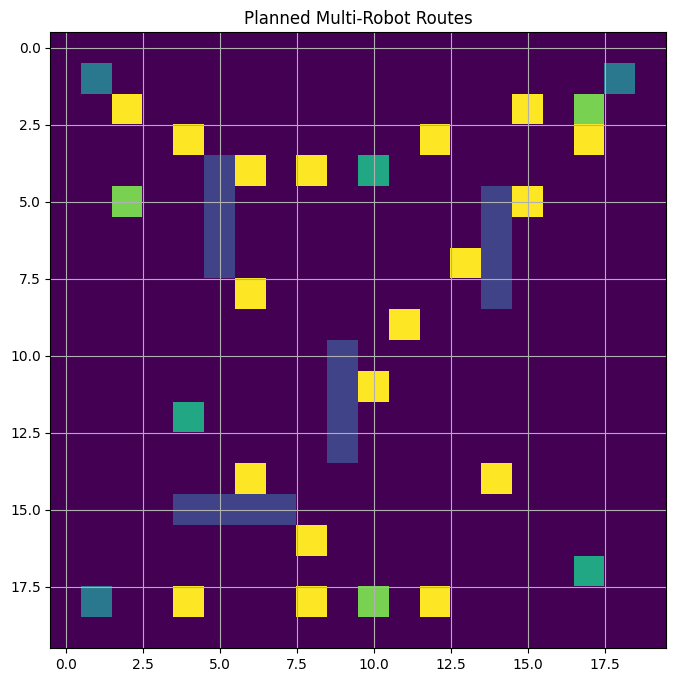

In [11]:
# Display Planned Routes
route_grid = grid.copy()

for p in path_A:
    if route_grid[p] == 0:
        route_grid[p] = 5

for p in path_B:
    if route_grid[p] == 0:
        route_grid[p] = 5

for p in path_C:
    if route_grid[p] == 0:
        route_grid[p] = 5

plt.figure(figsize=(8,8))

plt.imshow(route_grid,cmap="viridis")

plt.title("Planned Multi-Robot Routes")

plt.grid(True)

plt.show()

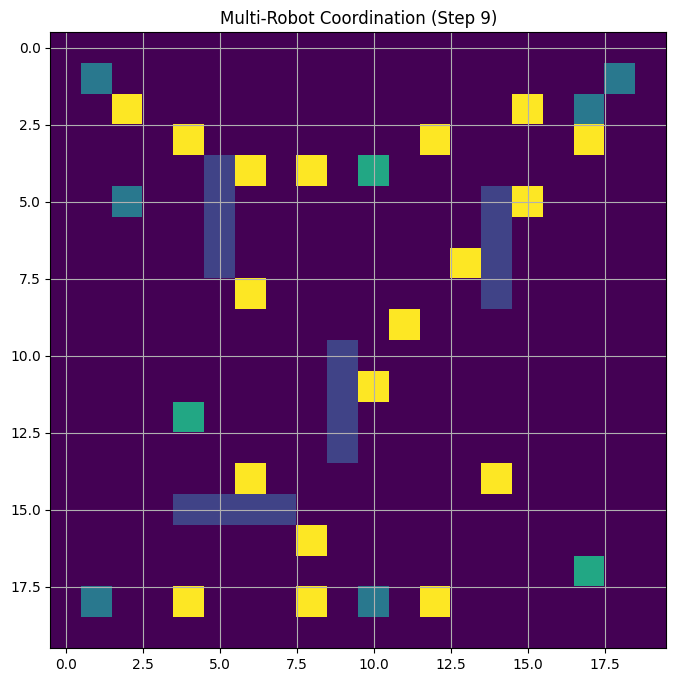

✅ All Robots Completed Their Tasks


In [12]:
# Animated Multi-Robot Movement
from IPython.display import clear_output
import time

max_steps = max(len(path_A), len(path_B), len(path_C))

for step in range(max_steps):

    clear_output(wait=True)

    display_grid = grid.copy()

    # Draw visited paths
    for p in path_A[:min(step, len(path_A))]:
        if display_grid[p] == 0:
            display_grid[p] = 5

    for p in path_B[:min(step, len(path_B))]:
        if display_grid[p] == 0:
            display_grid[p] = 5

    for p in path_C[:min(step, len(path_C))]:
        if display_grid[p] == 0:
            display_grid[p] = 5

    # Robot A
    if step < len(path_A):
        display_grid[path_A[step]] = 2

    # Robot B
    if step < len(path_B):
        display_grid[path_B[step]] = 2

    # Robot C
    if step < len(path_C):
        display_grid[path_C[step]] = 2

    plt.figure(figsize=(8,8))
    plt.imshow(display_grid,cmap="viridis")
    plt.title(f"Multi-Robot Coordination (Step {step+1})")
    plt.grid(True)
    plt.show()

    time.sleep(0.5)

print("✅ All Robots Completed Their Tasks")

In [13]:
# Professional Warehouse Colors
from matplotlib.colors import ListedColormap, BoundaryNorm

colors = [

    "white",        # Empty

    "black",        # Shelf

    "dodgerblue",   # Robot

    "orange",       # Package

    "limegreen",    # Delivery

    "gold"          # Route

]

cmap = ListedColormap(colors)

bounds = [-0.5,0.5,1.5,2.5,3.5,4.5,5.5]

norm = BoundaryNorm(bounds,cmap.N)

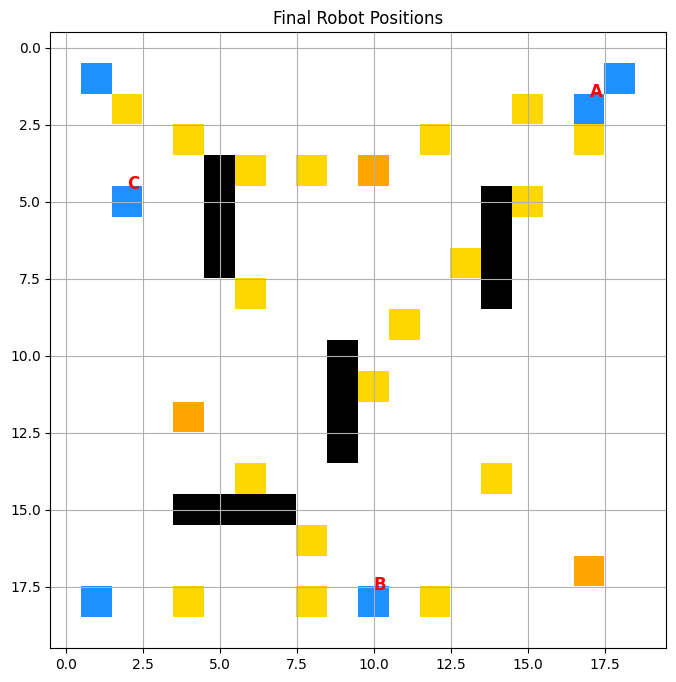

In [14]:
# Robot Labels
plt.figure(figsize=(8,8))

plt.imshow(display_grid,cmap=cmap,norm=norm)

robot_positions = {

    "A":path_A[-1],

    "B":path_B[-1],

    "C":path_C[-1]

}

for name,pos in robot_positions.items():

    plt.text(pos[1],
             pos[0]-0.4,
             name,
             color="red",
             fontsize=12,
             weight="bold")

plt.title("Final Robot Positions")

plt.grid(True)

plt.show()

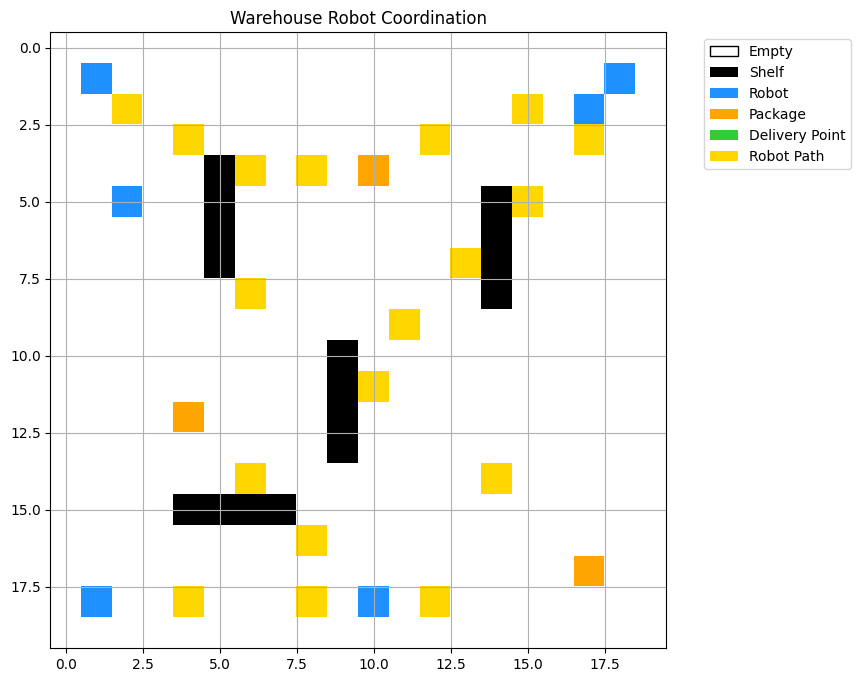

In [15]:
# Professional Legend
from matplotlib.patches import Patch

legend_elements = [

    Patch(facecolor="white",edgecolor="black",label="Empty"),

    Patch(facecolor="black",label="Shelf"),

    Patch(facecolor="dodgerblue",label="Robot"),

    Patch(facecolor="orange",label="Package"),

    Patch(facecolor="limegreen",label="Delivery Point"),

    Patch(facecolor="gold",label="Robot Path")

]

plt.figure(figsize=(8,8))

plt.imshow(display_grid,cmap=cmap,norm=norm)

plt.legend(handles=legend_elements,
           bbox_to_anchor=(1.05,1),
           loc="upper left")

plt.title("Warehouse Robot Coordination")

plt.grid(True)

plt.show()

In [16]:
# Mission Dashboard
robots_active = 3
tasks_completed = 3
collisions = 0

print("="*50)
print("      MULTI-ROBOT MISSION REPORT")
print("="*50)

print(f"Robots Active      : {robots_active}")
print(f"Tasks Assigned     : 3")
print(f"Tasks Completed    : {tasks_completed}")
print(f"Collisions         : {collisions}")
print(f"Mission Status     : SUCCESS")

print("="*50)

      MULTI-ROBOT MISSION REPORT
Robots Active      : 3
Tasks Assigned     : 3
Tasks Completed    : 3
Collisions         : 0
Mission Status     : SUCCESS


In [17]:
# Export JSON
report = {

    "robots":robots_active,

    "tasks_assigned":3,

    "tasks_completed":tasks_completed,

    "collisions":collisions,

    "status":"Mission Complete"

}

with open("multi_robot_report.json","w") as file:

    json.dump(report,file,indent=4)

print("✅ JSON Report Saved")

✅ JSON Report Saved


In [18]:
# Mission Summary
summary = f"""
==================================================
          MULTI-ROBOT MISSION REPORT
==================================================

Robots Active      : {robots_active}
Tasks Assigned     : 3
Tasks Completed    : {tasks_completed}
Collisions         : {collisions}
Mission Status     : SUCCESS

==================================================
"""

with open("mission_summary.txt","w") as file:

    file.write(summary)

print(summary)


          MULTI-ROBOT MISSION REPORT

Robots Active      : 3
Tasks Assigned     : 3
Tasks Completed    : 3
Collisions         : 0
Mission Status     : SUCCESS




In [19]:
# Download Outputs
plt.imsave("warehouse_map.png",display_grid,cmap=cmap)

from google.colab import files

files.download("warehouse_map.png")
files.download("multi_robot_report.json")
files.download("mission_summary.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>